## What are the most demanded skills for the top 3 most popular data roles?

Methodology:

1- Clean-up skill column  
2- Calculate skill count based on `Job_title`  
3- Calculate skill percentage  
4- Plot final findings  

### Import Libraries and Data

In [24]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt  

# Load Data
df = pd.read_excel('data_for_10,000_employees.xlsx')

# Data Cleanup 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

### Filter Data for the United States

###### Filter the data for the market of the United States.

In [25]:
df_US = df[df['country'] == 'United States']

### Explode Skills 

###### Converts the ```job_skills``` column from string representations of lists into actual list objects and then expands these lists so each skill appears in its own row. It then displays the ```job_title``` and ```job_skills``` columns, allowing us to analyze the distribution of skills across different data job titles.

In [26]:
df_skills = df_US.explode('job_skills')

df_skills[['job_title_short', 'job_skills']]

,job_title_short,job_skills
5,Sales Executive,Pipeline Management
5,Sales Executive,Salesforce
5,Sales Executive,Lead Generation
5,Sales Executive,Sales Analytics
17,Software Engineer,Java
...,...,...
9990,Software Engineer,SQL
9990,Software Engineer,CI/CD
9990,Software Engineer,Agile
9990,Software Engineer,React


### Count Skills per Job Title

###### Groups DataFrame by ```job_skills``` and ```job_title_short```, counting the occurrences of each skill within each job title. Then resets the index of the Series to turn it back into a DataFrame and renames the series holding the count to 'count'. The final DataFrame, ```df_skills_count```, shows the frequency of each skill with each job title.

In [27]:
# Group by job_skills and job_title_short and count the number of occurrences
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

# Name the count column as 'skill_count'
df_skills_count = df_skills_count.reset_index(name='skill_count')

# Sort the values by skill_count in descending order
df_skills_count = df_skills_count.sort_values(by='skill_count', ascending=False)

df_skills_count

,job_skills,job_title_short,skill_count
303,Python,Software Engineer,123
148,Git,Software Engineer,119
309,REST APIs,Software Engineer,97
184,JavaScript,Software Engineer,94
183,Java,Software Engineer,93
...,...,...,...
139,Firewalls,Cybersecurity Analyst,1
154,HIPAA,Pharmacist,1
175,Intellectual Property,Lawyer,1
48,C++,Machine Learning Engineer,1


### Create List of Top 3 Roles

Focus: Software Engineers, Marketing Managers, and Data Analysts  
###### Filter the job titles based on the most popular.

In [28]:
job_titles = df_skills_count['job_title_short'].unique().tolist()

job_titles = sorted(job_titles[:3])

job_titles

['Data Analyst', 'Marketing Manager', 'Software Engineer']

### Plot Skill Counts

###### Creates a stacked horizontal bar chart for the top 5 skills for Top 3 roles, displaying the frequency of each skill.

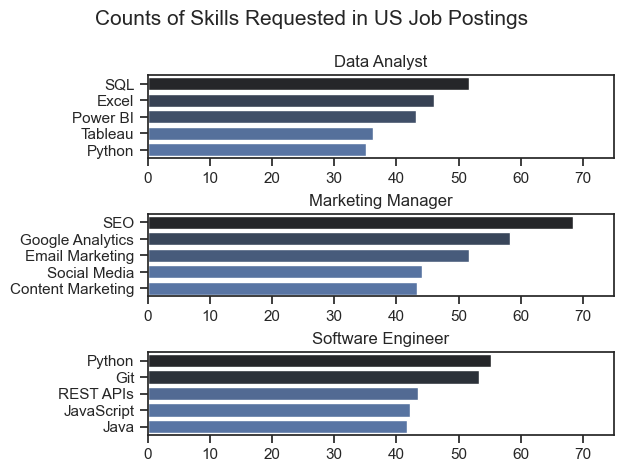

In [29]:
fig, ax = plt.subplots(len(job_titles), 1)

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percentage', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 75)

fig.suptitle('Counts of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout(h_pad=0.5)
plt.show()


### Convert Counts to Percentages
##### Focus: Counts don't show what portions of jobs are requesting these skills

###### So we'll convert the counts into percentages which helps us understand how each job title represents relative to the entire dataset.

###### Before we can calculate the percentages we need the total counts for the jobs posted by job title. Calculate the frequency of each job title using the value_counts() method on the ```job_title_short``` column. Then reset the index to transform the Series into a DataFrame and renames the columns to ```job_title_short``` and total. The DataFrame ```df_job_title_count``` now holds a list of job titles alongside their total occurrences.

In [30]:
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name='jobs_total')

df_job_title_count

,job_title_short,jobs_total
0,Software Engineer,223
1,Customer Support,201
2,Data Analyst,174
3,Marketing Manager,120
4,Sales Executive,116
5,Accountant,91
6,HR Specialist,88
7,Teacher,76
8,UI/UX Designer,65
9,Content Writer,65


###### Then we calculate the percentages. First merge ```df_skills_count``` and ```df_job_title_count```, based on the 'job_title_short' column, ensuring each skill count is associated with the total number of job postings for that title. Then calculate the percentage of each skill within its job title by dividing the skill count by the total job postings and multiplying by 100, adding this new data as a 'percentage' column.

In [31]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')

df_skills_perc['skill_percentage'] = 100 * (df_skills_perc['skill_count'] / df_skills_perc['jobs_total'])

df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_percentage
0,Python,Software Engineer,123,223,55.156951
1,Git,Software Engineer,119,223,53.363229
2,REST APIs,Software Engineer,97,223,43.497758
3,JavaScript,Software Engineer,94,223,42.152466
4,Java,Software Engineer,93,223,41.704036
...,...,...,...,...,...
427,Firewalls,Cybersecurity Analyst,1,11,9.090909
428,HIPAA,Pharmacist,1,12,8.333333
429,Intellectual Property,Lawyer,1,9,11.111111
430,C++,Machine Learning Engineer,1,8,12.500000


### Plot Percentage Count

###### Filters and sorts a DataFrame to get the top 5 skills percentages for these top 3 roles. After sorting the skills by descending percentage, reverse the order of these top 5 entries to use in a horizontal bar plot, which by default starts plotting from the bottom.

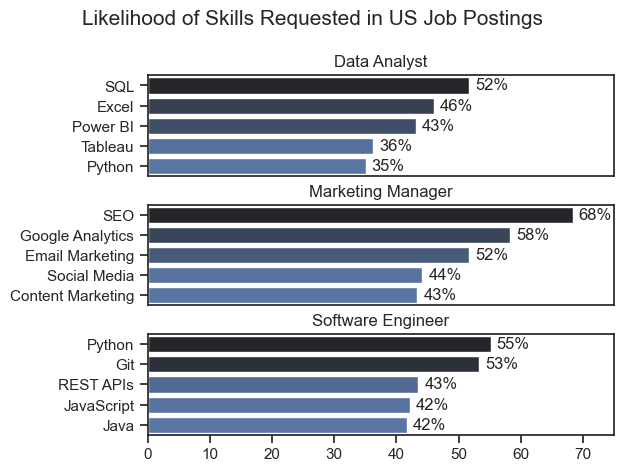

In [32]:
fig, ax = plt.subplots(len(job_titles), 1)

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percentage', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 75)

    # remove the x-axis tick labels for better readability
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

    # label the percentage on the bars
    for n, v in enumerate(df_plot['skill_percentage']):
        ax[i].text(v + 1, n, f'{round(v)}%', va='center')


fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout(h_pad=0.5)
plt.show()
